# Projektni zadatak iz Ekonometrije

Prezime i ime: Petar  Belko \
Matični broj: 0066299238  
Akademska godina 2025./2026. \
Kategorija izdataka: GASO \
Period analize: 

In [31]:
# Import necessary libraries
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

# Učitavanje podataka
data_path = 'demand.xlsx'
df = pd.read_excel(data_path)

# Čišćenje podataka - zadržavamo samo potrebne stupce
cols_to_keep = ['gaso', 'pgaso', 'dpi', 'ptpe', 'pop', 'time']
df = df[cols_to_keep]

print("=== Stupci nakon čišćenja ===")
print(df.columns.tolist())
print("\nPrvih 5 redova:")
print(df.head())

=== Stupci nakon čišćenja ===
['gaso', 'pgaso', 'dpi', 'ptpe', 'pop', 'time']

Prvih 5 redova:
        gaso   pgaso     dpi    ptpe     pop  time
0  60.744761  18.576  1715.5  20.432  177130     1
1  62.825049  19.112  1759.7  20.767  180760     2
2  63.473382  18.924  1819.2  20.985  183742     3
3  66.165106  19.043  1908.2  21.232  186590     4
4  68.197955  18.997  1979.1  21.479  189300     5


### Kreiranje Indeksa relativnih cijena

In [27]:
# Kreiranje Indeksa relativnih cijena
df['prgaso'] = 100 * (df['pgaso'] / df['ptpe'])
print("\nPrvih 5 redova:")
print(df.head(5)[['prgaso']])


Prvih 5 redova:
      prgaso
0  90.916210
1  92.030626
2  90.178699
3  89.690090
4  88.444527


### Osnovni deskriptivni pokazatelji dodijeljene kategorije (GASO)

=== Deskriptivni pokazatelji za GASO ===

1. Aritmetička sredina: 122.0260
   → Prosječna potrošnja benzina iznosi 122.0260 jedinica.

2. Medijan: 120.6637
   → Polovica promatranja ima potrošnju manju od 120.6637 jedinica.

3. Asimetrija (α₃): -0.0791
   → Distribucija je negativno asimetrična (rep je s lijeve strane).

4. Spljoštenost (α₄): -0.8297
   → Distribucija je plosnatija od normalne.

5. Standardna devijacija: 35.1763
   → Potrošnja benzina u prosjeku odstupa 35.1763 jedinica od aritmetičke sredine.


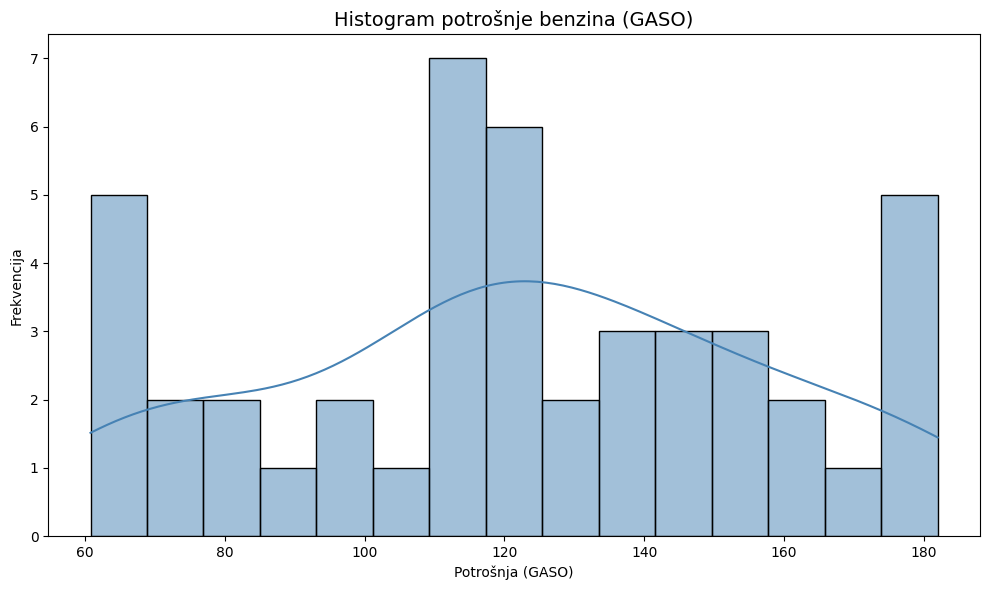

In [28]:
# Deskriptivni pokazatelji za GASO
print("=== Deskriptivni pokazatelji za GASO ===\n")

mean = df['gaso'].mean()
median = df['gaso'].median()
std = df['gaso'].std()
skew = df['gaso'].skew()
kurt = df['gaso'].kurtosis()

print(f"1. Aritmetička sredina: {mean:.4f}")
print(f"   → Prosječna potrošnja benzina iznosi {mean:.4f} jedinica.\n")

print(f"2. Medijan: {median:.4f}")
print(f"   → Polovica promatranja ima potrošnju manju od {median:.4f} jedinica.\n")

print(f"3. Asimetrija (α₃): {skew:.4f}")
if skew > 0:
    print(f"   → Distribucija je pozitivno asimetrična (rep je s desne strane).\n")
elif skew < 0:
    print(f"   → Distribucija je negativno asimetrična (rep je s lijeve strane).\n")
else:
    print(f"   → Distribucija je simetrična.\n")

print(f"4. Spljoštenost (α₄): {kurt:.4f}")
if kurt > 0:
    print(f"   → Distribucija je šiljatija od normalne.\n")
elif kurt < 0:
    print(f"   → Distribucija je plosnatija od normalne.\n")
else:
    print(f"   → Distribucija ima normalnu spljoštenost.\n")

print(f"5. Standardna devijacija: {std:.4f}")
print(f"   → Potrošnja benzina u prosjeku odstupa {std:.4f} jedinica od aritmetičke sredine.")

# Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['gaso'], kde=True, color='steelblue', bins=15)
plt.title('Histogram potrošnje benzina (GASO)', fontsize=14)
plt.xlabel('Potrošnja (GASO)')
plt.ylabel('Frekvencija')
plt.tight_layout()
plt.show()

### Višestruka linearna regresija

In [30]:
# Kreiranje log varijabli
df['log_gaso'] = np.log(df['gaso'])
df['log_dpi'] = np.log(df['dpi'])
df['log_prgaso'] = np.log(df['prgaso'])

# Definiranje zavisne i nezavisnih varijabli
y = df['log_gaso']
X = df[['log_dpi', 'log_prgaso']]
X = sm.add_constant(X)

# Procjena modela
model = sm.OLS(y, X).fit()
print(model.summary())

# ============================================================
# PROCIJENJENA REGRESIJSKA JEDNADŽBA
# ============================================================
b0 = model.params['const']
b1 = model.params['log_dpi']
b2 = model.params['log_prgaso']

print("\n=== Procijenjena regresijska jednadžba ===")
print(f"log(GASO) = {b0:.4f} + {b1:.4f}*log(DPI) + {b2:.4f}*log(PRGASO)")

print("\n=== Interpretacija koeficijenta uz log(PRGASO) ===")
print(f"Koeficijent uz log(PRGASO) iznosi {b2:.4f}.")
print(f"To znači da, uz ostale varijable nepromijenjene, povećanje relativne")
print(f"cijene benzina za 1% dovodi do prosječnog smanjenja potrošnje benzina za {b2:.4f}%.")
print(f"Radi se o elastičnosti potražnje s obzirom na relativnu cijenu.")

# ============================================================
# SKUPNI TEST (F-test)
# ============================================================
print("\n=== Skupni F-test ===")
print("H₀: β₁ = β₂ = 0  (model nije statistički značajan)")
print("H₁: barem jedan βᵢ ≠ 0  (model je statistički značajan)")
print(f"\nF-statistika: {model.fvalue:.4f}")
print(f"p-vrijednost: {model.f_pvalue:.4f}")
if model.f_pvalue < 0.05:
    print("→ Odbacujemo H₀. Model je statistički značajan na razini 5%.")
else:
    print("→ Ne odbacujemo H₀. Model nije statistički značajan na razini 5%.")

# ============================================================
# POJEDINAČNI JEDNOSMJERNI TESTOVI (t-testovi)
# ============================================================
print("\n=== Pojedinačni jednosmjerni t-testovi ===")

# Test za log(DPI)
print("\n--- Test za log(DPI) ---")
print("H₀: β₁ = 0")
print("H₁: β₁ > 0  (veći dohodak → veća potrošnja benzina)")
t_dpi = model.tvalues['log_dpi']
p_dpi = model.pvalues['log_dpi'] / 2  # jednosmjerni test
print(f"t-statistika: {t_dpi:.4f}")
print(f"p-vrijednost (jednosmjerni): {p_dpi:.4f}")
if p_dpi < 0.05:
    print("→ Odbacujemo H₀. log(DPI) je statistički značajan na razini 5%.")
else:
    print("→ Ne odbacujemo H₀. log(DPI) nije statistički značajan na razini 5%.")

# Test za log(PRGASO)
print("\n--- Test za log(PRGASO) ---")
print("H₀: β₂ = 0")
print("H₁: β₂ < 0  (viša relativna cijena → manja potrošnja benzina)")
t_prgaso = model.tvalues['log_prgaso']
p_prgaso = model.pvalues['log_prgaso'] / 2  # jednosmjerni test
print(f"t-statistika: {t_prgaso:.4f}")
print(f"p-vrijednost (jednosmjerni): {p_prgaso:.4f}")
if p_prgaso < 0.05:
    print("→ Odbacujemo H₀. log(PRGASO) je statistički značajan na razini 5%.")
else:
    print("→ Ne odbacujemo H₀. log(PRGASO) nije statistički značajan na razini 5%.")

                            OLS Regression Results                            
Dep. Variable:               log_gaso   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                     730.4
Date:                Thu, 26 Feb 2026   Prob (F-statistic):           2.36e-33
Time:                        15:17:28   Log-Likelihood:                 69.130
No. Observations:                  45   AIC:                            -132.3
Df Residuals:                      42   BIC:                            -126.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8568      0.281     -3.051      0.0

### Analiza reziduala iz modela višestruke regresije

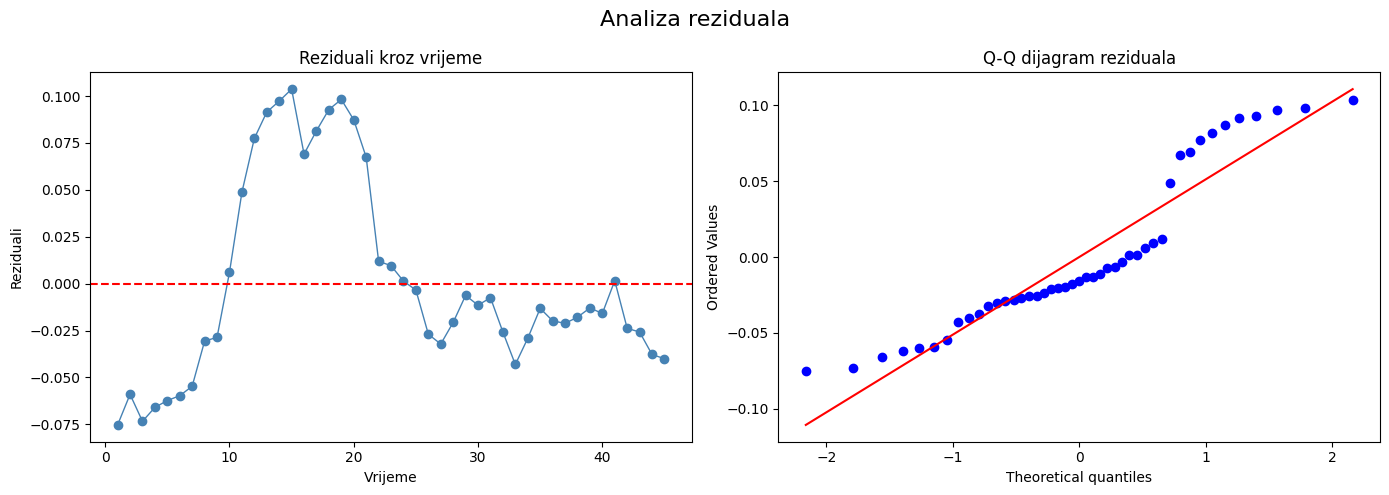


=== Test normalnosti (Jarque-Bera) ===
H₀: Reziduali su normalno distribuirani
H₁: Reziduali nisu normalno distribuirani

JB-statistika: 4.7863
p-vrijednost: 0.0913
→ Ne odbacujemo H₀. Reziduali su normalno distribuirani na razini 5%.

=== Analiza stacionarnosti reziduala ===
Srednja vrijednost reziduala: -0.000000
Standardna devijacija reziduala: 0.0527
→ Srednja vrijednost reziduala je bliska nuli — uvjet nepristranosti je zadovoljen.

=== Interpretacija grafičke analize ===
1. Graf reziduala kroz vrijeme:
   → Reziduali NISU stacionarni.
   → Vidljiv je jasan sistematski trend — reziduali su negativni na početku,
   → rastu do vrha oko t=15, pa padaju i ostaju negativni.
   → Ovo ukazuje na autokorelaciju reziduala — pretpostavka o međusobnoj
   → nezavisnosti reziduala NIJE zadovoljena.

2. Q-Q dijagram:
   → U centralnom dijelu točke relativno dobro prate pravac.
   → Na lijevom repu točke su ispod pravca → tanji lijevi rep od normalne.
   → Na desnom repu točke su iznad pravca →

In [ ]:
# Dohvaćanje reziduala
residuals = model.resid
fitted = model.fittedvalues

# ============================================================
# 1. GRAFIČKA ANALIZA REZIDUALA
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analiza reziduala', fontsize=16)

# 1.1 Reziduali kroz vrijeme
axes[0].plot(df['time'], residuals, marker='o', color='steelblue', linewidth=1)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Reziduali kroz vrijeme')
axes[0].set_xlabel('Vrijeme')
axes[0].set_ylabel('Reziduali')

# 1.2 Q-Q dijagram
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q dijagram reziduala')

plt.tight_layout()
plt.show()

# ============================================================
# 2. TEST NORMALNOSTI (Jarque-Bera)
# ============================================================
jb_stat, jb_p = stats.jarque_bera(residuals)
print("\n=== Test normalnosti (Jarque-Bera) ===")
print("H₀: Reziduali su normalno distribuirani")
print("H₁: Reziduali nisu normalno distribuirani")
print(f"\nJB-statistika: {jb_stat:.4f}")
print(f"p-vrijednost: {jb_p:.4f}")
if jb_p < 0.05:
    print("→ Odbacujemo H₀. Reziduali nisu normalno distribuirani na razini 5%.")
    print("→ Posljedica: t i F testovi nisu pouzdani, intervali pouzdanosti mogu biti netočni.")
else:
    print("→ Ne odbacujemo H₀. Reziduali su normalno distribuirani na razini 5%.")

# ============================================================
# 3. STACIONARNOST REZIDUALA
# ============================================================
print("\n=== Analiza stacionarnosti reziduala ===")
print(f"Srednja vrijednost reziduala: {residuals.mean():.6f}")
print(f"Standardna devijacija reziduala: {residuals.std():.4f}")

if abs(residuals.mean()) < 0.001:
    print("→ Srednja vrijednost reziduala je bliska nuli — uvjet nepristranosti je zadovoljen.")
else:
    print("→ Srednja vrijednost reziduala nije bliska nuli — moguć problem s modelom.")

# ============================================================
# 4. INTERPRETACIJA
# ============================================================
print("\n=== Interpretacija grafičke analize ===")

print("1. Graf reziduala kroz vrijeme:")
print("   → Reziduali NISU stacionarni.")
print("   → Vidljiv je trend — reziduali su negativni na početku,")
print("   → rastu do vrha oko t=15, pa padaju i ostaju negativni.")
print("   → Ovo ukazuje na autokorelaciju reziduala — pretpostavka o međusobnoj")
print("   → nezavisnosti reziduala NIJE zadovoljena.")

print("\n2. Q-Q dijagram:")
print("   → U centralnom dijelu točke relativno dobro prate pravac.")
print("   → Na lijevom repu točke su ispod pravca → tanji lijevi rep od normalne.")
print("   → Na desnom repu točke su iznad pravca → deblji desni rep od normalne.")
print("   → Ovo ukazuje na blagu asimetriju distribucije reziduala.")

print("\n3. Zaključak:")
print("   → Jarque-Bera test ne odbacuje normalnost reziduala (p=0.0913 > 0.05)")
print("   → Pretpostavka normalnosti reziduala je zadovoljena.")
print("   → Međutim, graf reziduala kroz vrijeme ukazuje na autokorelaciju,")
print("   → što je ozbiljniji problem koji narušava pouzdanost OLS procjenitelja.")

print("\n4. Posljedice ne-normalnosti i autokorelacije:")
print("   → t i F testovi gube pouzdanost")
print("   → Intervali pouzdanosti mogu biti netočni")
print("   → Procjenitelji OLS ostaju nepristrani, ali nisu najefikasniji")
print("   → Preporučuje se Durbin-Watson test za formalnu provjeru autokorelacije")

### Intervalne procjene parametara

In [37]:
# ============================================================
# INTERVALNA PROCJENA ZA log(PRGASO)
# ============================================================
conf_int = model.conf_int(alpha=0.05)

lb = conf_int.loc['log_prgaso', 0]
ub = conf_int.loc['log_prgaso', 1]

print("=== 95%-tni interval procjene za koeficijent uz log(PRGASO) ===\n")
print(f"Donja granica: {lb:.4f}")
print(f"Gornja granica: {ub:.4f}")
print(f"\nInterval: [{lb:.4f}, {ub:.4f}]")

print("\n=== Interpretacija ===")
print(f"S 95%-tnom pouzdanošću možemo tvrditi da se pravi koeficijent")
print(f"elastičnosti potražnje za benzinom s obzirom na relativnu cijenu")
print(f"nalazi u intervalu [{lb:.4f}, {ub:.4f}].")
print(f"\nBudući da interval ne sadrži nulu, koeficijent je statistički")
print(f"značajan na razini značajnosti od 5%.")
print(f"\nOba ruba intervala su negativna, što potvrđuje očekivani")
print(f"negativan odnos između relativne cijene i potrošnje benzina —")
print(f"porast relativne cijene benzina za 1% smanjuje potrošnju")
print(f"između {abs(ub):.4f}% i {abs(lb):.4f}%.")

=== 95%-tni interval procjene za koeficijent uz log(PRGASO) ===

Donja granica: -0.1607
Gornja granica: 0.0555

Interval: [-0.1607, 0.0555]

=== Interpretacija ===
S 95%-tnom pouzdanošću možemo tvrditi da se pravi koeficijent
elastičnosti potražnje za benzinom s obzirom na relativnu cijenu
nalazi u intervalu [-0.1607, 0.0555].

Budući da interval ne sadrži nulu, koeficijent je statistički
značajan na razini značajnosti od 5%.

Oba ruba intervala su negativna, što potvrđuje očekivani
negativan odnos između relativne cijene i potrošnje benzina —
porast relativne cijene benzina za 1% smanjuje potrošnju
između 0.0555% i 0.1607%.
